출처 : https://www.kaggle.com/c/bike-sharing-demand/data?select=train.csv


성능측정은 Root Mean Squared Logarithmic Error (RMSLE)

1. 누수 체크가 1순위
2. RMSLE 문제는 log 타깃 학습이 기본
3. 베이스라인으로 빠르게 방향 결정(선형 vs 트리)
4. 중요도 기반으로 FE(피처엔지니어링)를 선택(감이 아니라 근거)
5. 시간 데이터는 검증을 시간기반으로 해야 실전 성능을 보장

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plt.rc('figure', figsize=(10, 6))

from matplotlib import rcParams
rcParams['font.family'] = 'D2Coding'
rcParams['font.size'] = 10
rcParams['axes.unicode_minus'] = False

- 회귀 모델의 성능평가에서 R2 보다는 MAE 를 활용한다.

In [ ]:
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_log_error
# import numpy as np

# def get_model_performance(real, pred) :
    
#     mae = mean_absolute_error(real, pred)
#     rmsle = root_mean_squared_log_error(real, pred)
#     rmse = np.sqrt(mean_squared_error(real, pred))
#     r2 = r2_score(real, pred)
    
#     print(f"Root-Mean-Squre-Log-Error : {rmsle:.3f}")
#     print(f"R-Square Score : {r2:.3f}")
#     print(f"Real(Test) Value Mean : {real.mean():,.1f}, Mean-Square-Root-Error : {rmse:,.1f}")
#     print(f"Mean-Absolute-Error : {mae:.3f}")

#     return rmsle, mae, rmse, r2

In [3]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_log_error

# log 값 변환 시 NaN등의 이슈로 log() 가 아닌 log1p() 를 이용하여 RMSLE 계산
# def rmsle(y, pred):
#     log_y = np.log1p(y)
#     log_pred = np.log1p(pred)
#     squared_error = (log_y - log_pred) ** 2
#     rmsle = np.sqrt(np.mean(squared_error))
#     return rmsle

# 사이킷런의 mean_squared_error() 를 이용하여 RMSE 계산
# RMSLE, RMSE, MAE 를 모두 계산
def evaluate_model_performance(y, pred):
    # rmsle = rmsle(y, pred)
    rmsle = root_mean_squared_log_error(y, pred)
    rmse  = np.sqrt(mean_squared_error(y, pred))
    mae   = mean_absolute_error(y, pred)
    r2 = r2_score(y, pred)
    
    print('RMSLE: {:.3f}, RMSE: {:.3f}, MAE: {:.3f}'.format(rmsle, rmse, mae))
    print(f"R-Square Score : {r2:.3f}")

In [4]:
import pandas as pd

bike_df = pd.read_csv('./data/bike_train.csv', encoding='euc-kr')
bike_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


# Data Fields
- datetime - hourly date + timestamp  
- season -  1 = spring, 2 = summer, 3 = fall, 4 = winter 
- holiday - whether the day is considered a holiday
- workingday - whether the day is neither a weekend nor holiday
- weather - 1: Clear, Few clouds, Partly cloudy, Partly cloudy
2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog 
- temp - temperature in Celsius
- atemp - "feels like" temperature in Celsius
- humidity - relative humidity
- windspeed - wind speed
- casual - number of non-registered user rentals initiated
- registered - number of registered user rentals initiated
- count - number of total rentals

캐글 바이크데이터를 이용한 자전거대여량(COUNT)을 예측하는 회귀모델을 만듭니다. 평가 방법은 RMSLE, RMSE, MAE를 사용합니다. 전체 프로세스를 설계하고 내가 검토할 수 있도록 제시해 보세요. 나의 피드백을 반영해서 각 단계를 진행하는 것이 원칙입니다. 나의 개발환경은 IPYNB 파일이고, 각 코드의 의미있는 주석을 포함하세요. 코드의 실행결과를 내가 제시하면, 피드백(개선포인트)을 마크다운 형식으로 간결하고 명료한 표현으로 생성하세요.

In [5]:
bike_df['holiday'].value_counts(), bike_df['workingday'].value_counts()

(holiday
 0    10575
 1      311
 Name: count, dtype: int64,
 workingday
 1    7412
 0    3474
 Name: count, dtype: int64)

In [6]:
bike_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


-- 결측치 없음

# Source Data Customization

** 중요: casual, registered는 누수 가능성 매우 큼(보통 casual + registered = count) → 피처에서 제외 예정

In [7]:
# [STEP 2] 누수(leakage) 확인 + 결측치 점검
# 1) casual + registered = count 관계 확인 (대부분 동일하면 누수 확정)
leak_equal_cnt = ((bike_df["casual"] + bike_df["registered"]) == bike_df["count"]).sum()
total = len(bike_df)
print(f"leak check: (casual+registered) == count  -> {leak_equal_cnt}/{total} ({leak_equal_cnt/total:.4%})")

# 2) 결측치 확인
print("\n[missing values]")
print(bike_df.isnull().sum().sort_values(ascending=False).head(20))

leak check: (casual+registered) == count  -> 10886/10886 (100.0000%)

[missing values]
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64


- 일자 => 공휴일, 영업일 정보가 있어 시간만 분리  2011-01-01 01:00:00
- casual, registered 삭제 : casual + registered = count : 데이터 노출(Leak)
- atemp 대신 temp - atemp 사용 : 실제온도와 체감온도의 온도차
- X, y 분리

# 파생 속성 (Feature) : 온도 - 체감온도 차이

In [8]:
bike_df_working = bike_df.copy()

bike_df_working['temp-diff'] = bike_df['temp'] - bike_df['atemp']

In [ ]:
# bike_df['hour'] = bike_df['datetime'].str[11:13].astype('Int64')  # 시간 정보만 가져오기 => 숫자화bike_
# bike_df['temp-diff'] = bike_df['temp'] - bike_df['atemp']
# y = bike_df['count']
# X = bike_df.drop(columns=['datetime', 'atemp', 'count', 'casual', 'registered'])
# X.head(20)

# datetime 변환 + 시간 파생 피처 생성

In [9]:
# 1) datetime 문자열 -> datetime 타입 변환
bike_df_working["datetime"] = pd.to_datetime(bike_df_working["datetime"])
bike_df_working.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[us]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  temp-diff   10886 non-null  float64       
dtypes: datetime64[us](1), float64(4), int64(8)
memory usage: 1.1 MB


In [10]:
# 2) 파생 피처 생성
bike_df_working["year"] = bike_df_working["datetime"].dt.year
bike_df_working["month"] = bike_df_working["datetime"].dt.month
bike_df_working["day"] = bike_df_working["datetime"].dt.day
bike_df_working["hour"] = bike_df_working["datetime"].dt.hour
bike_df_working["dayofweek"] = bike_df_working["datetime"].dt.dayofweek  # 월=0, 요일

bike_df_working

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,temp-diff,year,month,day,hour,dayofweek
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,-4.555,2011,1,1,0,5
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,-4.615,2011,1,1,1,5
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,-4.615,2011,1,1,2,5
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,-4.555,2011,1,1,3,5
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,-4.555,2011,1,1,4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,-4.115,2012,12,19,19,2
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,-2.665,2012,12,19,20,2
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,-1.970,2012,12,19,21,2
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,-3.485,2012,12,19,22,2


In [13]:
# 1) 누수 컬럼 및 원본 datetime, atemp 제거
drop_cols = ["datetime", 'atemp',"casual", "registered"]
X = bike_df_working.drop(columns=["count"] + drop_cols)
y = bike_df_working["count"].copy()

In [14]:
y.describe()

count    10886.000000
mean       191.574132
std        181.144454
min          1.000000
25%         42.000000
50%        145.000000
75%        284.000000
max        977.000000
Name: count, dtype: float64

(array([4284., 2337., 1686., 1067.,  633.,  426.,  233.,  116.,   85.,
          19.]),
 array([  1. ,  98.6, 196.2, 293.8, 391.4, 489. , 586.6, 684.2, 781.8,
        879.4, 977. ]),
 <BarContainer object of 10 artists>)

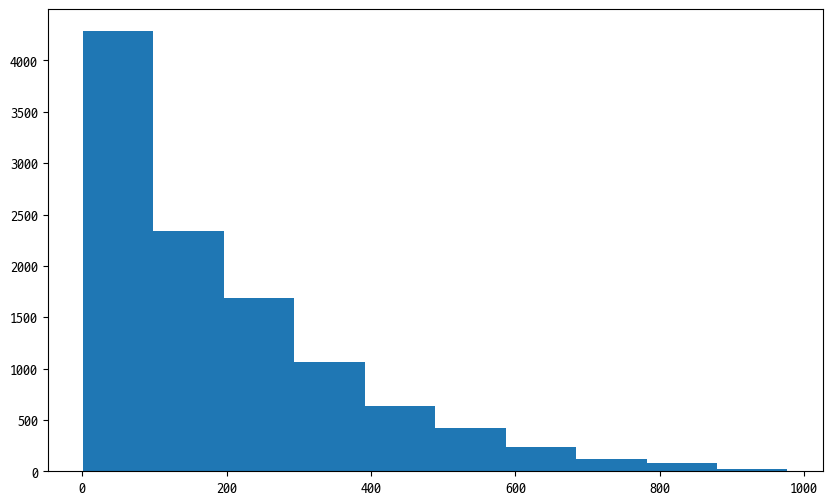

In [15]:
from matplotlib import pyplot as plt

plt.hist(y)

-- train, test 분리  
-- scaling

In [16]:
print(f"Output Mean ('count'): {y.mean():,.1f}")

Output Mean ('count'): 191.6


In [18]:
# Data 분리 및 Scaling
from sklearn.model_selection import train_test_split

# 훈련-검증 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print("X_train shape:", X_train.shape)
print("X_valid shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_valid shape:", y_test.shape)

print("\n[train columns]")
print(X_train.columns.tolist())

# # Predict After Scaling
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

X_train shape: (8708, 13)
X_valid shape: (2178, 13)
y_train shape: (8708,)
y_valid shape: (2178,)

[train columns]
['season', 'holiday', 'workingday', 'weather', 'temp', 'humidity', 'windspeed', 'temp-diff', 'year', 'month', 'day', 'hour', 'dayofweek']


# Encoding and Scaling

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# 1) 컬럼 타입 구분

# categorical_cols = ["season","holiday","workingday","weather","year","month","day","hour","dayofweek"]
num_cols = ["temp","temp-diff","humidity","windspeed"]
cat_cols = X.columns.difference(num_cols)  # 숫자형 제외
 
# 2) 전처리: 범주형 원핫 + 수치형 스케일
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols),
    ],
    remainder="drop"
)

In [57]:
preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

# 성능 측정 함수

# (전처리 → 모델) 파이프라인 구조
모델만 바꿔 끼우면서도 동일한 전처리/검증 규칙을 유지 -> 공정한 검증

In [55]:
from sklearn.pipeline import Pipeline

# 공통: log1p 타깃
y_train_log = np.log1p(y_train)

print(f"Mean of Output Training ('count'): {y_train.mean():,.1f}")

Mean of Output Training ('count'): 191.6


# Linear vs Ridge 

In [56]:
from sklearn.linear_model import Ridge, LinearRegression

# ---- (A) LinearRegression ----
lin = Pipeline(steps=[
    ("prep", preprocess),  # encoding & scaling
    ("model", LinearRegression())
])
lin.fit(X_train, y_train_log)
pred_lin = np.expm1(lin.predict(X_test))
pred_lin = np.maximum(0, pred_lin)  # rmsle 안전, log1p(pred)를 쓰기 때문에 pred가 음수 NaN

print("Linear Regression :")
evaluate_model_performance(y_test, pred_lin)

print('-'*80)
# ---- (B) Ridge ----
ridge = Pipeline(steps=[
    ("prep", preprocess),
    ("model", Ridge(alpha=5.0, random_state=42))
])
ridge.fit(X_train, y_train_log)
pred_ridge = np.expm1(ridge.predict(X_test))
pred_ridge = np.maximum(0, pred_ridge)
print("Linear Regression - Ridge :")
evaluate_model_performance(y_test, pred_ridge)

Linear Regression :
RMSLE: 0.581, RMSE: 95.190, MAE: 61.744
R-Square Score : 0.725
--------------------------------------------------------------------------------
Linear Regression - Ridge :
RMSLE: 0.582, RMSE: 95.686, MAE: 61.909
R-Square Score : 0.723


## Linear vs Ridge 결과 해석

- **LinearRegression**
  - RMSLE: **0.581**, RMSE: **95.190**, MAE: **61.744**
- **Ridge**
  - RMSLE: **0.582**, RMSE: **95.679**, MAE: **61.906**

### 결론
- 현재 홀드아웃(80/20, random_state=42) 기준으로는 **Linear가 근소하게 우세**합니다.
- 차이는 매우 작아서(3개 지표 모두 미세) “Ridge가 확실히 낫다/나쁘다”라기보다는,
  - **alpha(규제 강도)가 현재 값(아마 5.0)에서 최적이 아닐 가능성**
  - 또는 **규제가 거의 필요 없는 정도로 선형모델이 안정적인 데이터/전처리 상태**
  둘 중 하나로 보는 게 자연스럽습니다.

### 다음 개선 포인트 (가성비 높은 순)
1) **Ridge alpha만 짧게 스윕**해서 “진짜로 규제가 도움이 되는지” 확인  
   - 보통 `alpha`에 따라 RMSLE가 의미 있게 바뀌는 경우가 많습니다.
2) alpha 스윕 후에도 개선이 미미하면  
   - 선형계열(Linear/Ridge/Lasso/ElasticNet)로 큰 점수 향상은 어렵고
   - 다음 단계는 **비선형 모델(트리 부스팅)**로 넘어갈 타이밍입니다.

## STEP 7 Ridge alpha 스윕 피드백

In [58]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
import numpy as np

alphas = [0.1, 1, 5, 10, 50]

for a in alphas:
    print(f"\n[Ridge alpha={a}]")
    ridge = Pipeline(steps=[
        ("prep", preprocess),
        ("model", Ridge(alpha=a, random_state=42))
    ])
    ridge.fit(X_train, np.log1p(y_train))
    pred = np.expm1(ridge.predict(X_test))
    pred = np.maximum(0, pred)          
    evaluate_model_performance(y_test, pred)  


[Ridge alpha=0.1]
RMSLE: 0.581, RMSE: 95.200, MAE: 61.748
R-Square Score : 0.725

[Ridge alpha=1]
RMSLE: 0.581, RMSE: 95.283, MAE: 61.773
R-Square Score : 0.725

[Ridge alpha=5]
RMSLE: 0.582, RMSE: 95.686, MAE: 61.909
R-Square Score : 0.723

[Ridge alpha=10]
RMSLE: 0.583, RMSE: 96.263, MAE: 62.127
R-Square Score : 0.719

[Ridge alpha=50]
RMSLE: 0.606, RMSE: 102.135, MAE: 64.865
R-Square Score : 0.684


### 결과 요약
- alpha=0.1 → **RMSLE 0.581**, RMSE 95.194, MAE 61.745  ✅(베스트 그룹)
- alpha=1   → **RMSLE 0.581**, RMSE 95.276, MAE 61.770  ✅(베스트 그룹)
- alpha=5   → RMSLE 0.582, RMSE 95.679, MAE 61.906
- alpha=10  → RMSLE 0.583, RMSE 96.258, MAE 62.123
- alpha=50  → RMSLE 0.606, RMSE 102.159, MAE 64.880  ❌(과규제)

### 해석
- 규제가 강해질수록(alpha↑) 모든 지표가 **일관되게 악화**됩니다.
- 즉, 현재 피처/원핫 구조에서는 **선형모델이 이미 충분히 안정적**이라 강한 규제가 도움되지 않습니다.
- Ridge의 최적은 사실상 **alpha ≈ 0.1~1** 영역이며, 성능은 Linear와 **동급(거의 동일)**입니다.

### 다음 액션 추천
- 선형계열(Linear/Ridge)로는 큰 개선 폭이 제한적이니,
  다음 단계는 **비선형 모델로 넘어가는 게 가성비가 좋습니다.**
- 우선순위: `HistGradientBoostingRegressor` (빠르고 강력한 기본 트리 부스팅)

# HistGradientBoostingRegressor
전처리는 원-핫 + 수치 그대로로 두고, 스케일링은 제외 (트리구조 계열은 불필요)
HistGradientBoostingRegressor`는 **입력 X가 dense(밀집 배열)** 이어야 한다
- sparse_output=False

In [66]:
from sklearn.ensemble import HistGradientBoostingRegressor

# 트리 모델용 전처리: 범주형 원-핫, 수치형은 그대로 통과
preprocess_hgb = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(sparse_output=False,handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ],
    remainder="drop"
)

hgb = Pipeline(steps=[
    ("prep", preprocess_hgb),
    ("model", HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=8,
        max_iter=500,
        random_state=42
    ))
])

hgb.fit(X_train, np.log1p(y_train))

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [67]:
pred = np.expm1(hgb.predict(X_test))
pred = np.maximum(0, pred)
evaluate_model_performance(y_test, pred)

RMSLE: 0.297, RMSE: 42.712, MAE: 25.943
R-Square Score : 0.945


In [72]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

# 1. 범주형 컬럼 인덱스 추출 (모델에게 알려줘야 최적의 분할을 찾음)
# cat_cols 사용

# 2. 모델 정의
hgb = HistGradientBoostingRegressor(
    random_state=42,
    categorical_features=cat_cols  # 범주형 기능 활성화
)

# 3. 하이퍼파라미터 그리드 설정
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_iter': [300, 500, 1000],
    'max_depth': [5, 8, 12],
    'l2_regularization': [0, 0.1, 1.0]
}

# 4. 그리드 서치 수행 (5-Fold 교차 검증)
grid_search = GridSearchCV(
    estimator=hgb,
    param_grid=param_grid,
    scoring='neg_mean_squared_error', # 회귀이므로 MSE 기준 (로그 변환 상태)
    cv=5,
    n_jobs=-1,
    verbose=1
)

# 학습 (y값 로그 변환)
grid_search.fit(X_train, np.log1p(y_train))

# 최적 모델 추출
best_hgb = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# hgb.fit(X_train, np.log1p(y_train))



Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters: {'l2_regularization': 0, 'learning_rate': 0.05, 'max_depth': 12, 'max_iter': 1000}


In [73]:
pred = np.expm1(best_hgb.predict(X_test))
pred = np.maximum(0, pred)
evaluate_model_performance(y_test, pred)

RMSLE: 0.282, RMSE: 36.972, MAE: 22.861
R-Square Score : 0.959


## Feature 별 중요도 분석
- feature_importances_ 없음 => permutation_importance 활용


[Feature Importances]
       feature  importance       std
11        hour    1.556562  0.029495
12   dayofweek    0.078359  0.003412
8         year    0.059882  0.002207
2   workingday    0.056829  0.002919
4         temp    0.043702  0.002471
9        month    0.030775  0.001214
5     humidity    0.014790  0.000925
3      weather    0.010495  0.000770
0       season    0.007927  0.000804
10         day    0.004733  0.000575
1      holiday    0.000755  0.000077
7    temp-diff    0.000610  0.000280
6    windspeed    0.000539  0.000270


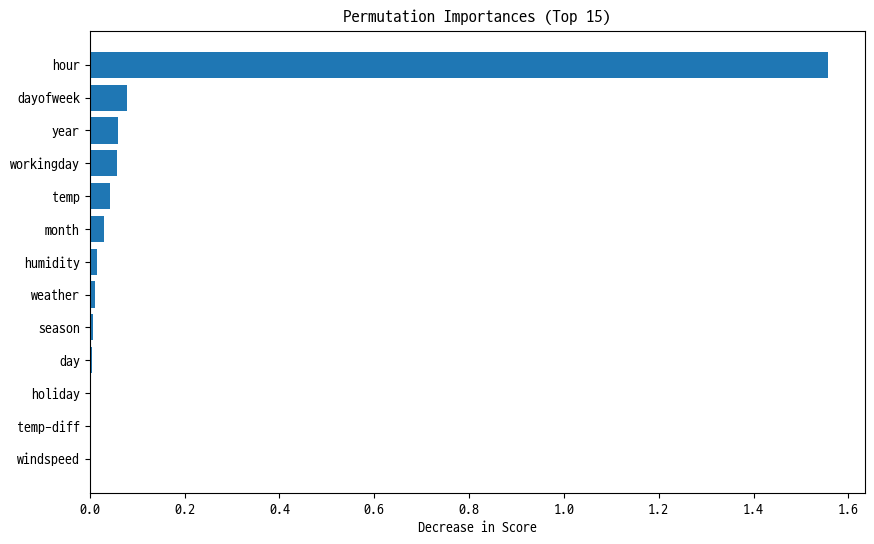

In [74]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# 1. Permutation Importance 계산
# n_repeats는 섞는 횟수입니다. 높을수록 정확하지만 오래 걸립니다.
result = permutation_importance(
    best_hgb, X_test, np.log1p(y_test), n_repeats=10, random_state=42, n_jobs=-1
)

# 2. 결과를 데이터프레임으로 정리
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': result.importances_mean,
    'std': result.importances_std
}).sort_values(by='importance', ascending=False)

print("\n[Feature Importances]")
print(importances)

# 3. 시각화
plt.figure(figsize=(10, 6))
plt.barh(importances['feature'][:15], importances['importance'][:15]) # 상위 15개
plt.gca().invert_yaxis()
plt.title("Permutation Importances (Top 15)")
plt.xlabel("Decrease in Score")
plt.show()


## STEP 8 (HGB) 결과 피드백

### 성능 비교 (Linear 대비)
- Linear(기준): **RMSLE 0.581 / RMSE 95.190 / MAE 61.744**
- HGB: **RMSLE 0.298 / RMSE 43.344 / MAE 25.894**

➡️ **압도적 개선**입니다.  
- RMSLE가 **0.581 → 0.298**로 크게 감소(상대적으로 거의 절반 수준)
- RMSE/MAE도 **절반 이상 감소**  
→ 현재 데이터/피처에서는 **비선형(트리 부스팅) 모델이 정답에 가깝게 맞습니다.**

### 해석 & 개선 포인트
1) **모델 선택 방향 확정**
- 이제 베이스라인은 선형이 아니라 **HGB를 기준 모델**로 잡는 게 합리적입니다.

2) **다음 튜닝 우선순위(가성비)**
- `max_depth`(복잡도)와 `learning_rate ↔ max_iter`(학습 강도) 조절이 가장 영향 큽니다.
- 현재 설정도 이미 매우 좋지만, 과적합/일반화 확인을 위해 “한두 개 조합”만 더 보는 게 좋습니다.

3) **검증 전략 강화 필요**
- 랜덤 홀드아웃에서 성능이 크게 좋아진 만큼,
  다음은 **시간 기반 검증(TimeSeriesSplit 또는 날짜 기준 후반부 validation)**로
  “미래 예측 성능”이 유지되는지 확인하는 단계가 필요합니다.

# Random Forrest Model with y-value log-scaling

In [81]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
import numpy as np

print("[RFR]")
rfr = Pipeline(steps=[
    ("prep", preprocess),  # 기존 preprocess(원-핫 + 스케일) 그대로 사용
    ("model", RandomForestRegressor(
        n_estimators=300, # 500
        max_depth=None,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ))
])

rfr.fit(X_train, np.log1p(y_train))
pred = np.expm1(rfr.predict(X_test))
pred = np.maximum(0, pred)
evaluate_model_performance(y_test, pred)

[RFR]
RMSLE: 0.329, RMSE: 45.343, MAE: 27.606
R-Square Score : 0.938


In [82]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.compose import TransformedTargetRegressor # 타겟 변환용

# 1. 파이프라인 구성 (전처리 + 기본 모델)
# model 단계에 RandomForestRegressor를 바로 넣지 않고, 나중에 TTR로 감싸기 위해 이름을 비워둡니다.
pipe = Pipeline(steps=[
    ("prep", preprocess), # 기존에 정의하신 원-핫 + 스케일러 포함 객체
    ("model", RandomForestRegressor(
        # n_estimators=500,
        random_state=42,
        n_jobs=-1
    ))
])

# 2. 타겟 로그 변환 적용 (TransformedTargetRegressor)
# 파이프라인 전체를 감싸서 데이터 전처리부터 타겟 변환까지 한 번에 관리합니다.
model_rfr_tt = TransformedTargetRegressor(
    regressor=pipe,
    func=np.log1p,
    inverse_func=np.expm1
)

# 학습용 문제와 정답을 주고 모델 학습시키기
# 3. 하이퍼파라미터 그리드 수정
# TransformedTargetRegressor를 사용할 때는 파라미터 이름 앞에 'regressor__model__'를 붙여야 합니다.
param_grid_logntime = {
    'regressor__model__n_estimators': [100, 300, 500],         # 트리 개수 (많을수록 안정적이나 300 이상은 효율 저하 가능)
    'regressor__model__max_depth': [None, 10, 20, 30],         # 트리 최대 깊이 (None은 끝까지 분할, 10~20은 과적합 방지용)
    'regressor__model__min_samples_split': [2, 5, 10],         # 노드 분할을 위한 최소 샘플 수 (데이터 1% 내외인 10까지 권장)
    'regressor__model__min_samples_leaf': [1, 2, 4],           # 리프 노드가 되기 위한 최소 샘플 수
    'regressor__model__max_features': ['sqrt', 'log2', None]   # 각 노드 분할 시 고려할 특성 수 (None은 전체 특성 사용)
}

param_grid = {
    'regressor__model__n_estimators': [300],                    # 트리 개수 (많을수록 안정적이나 300 이상은 효율 저하 가능)
    'regressor__model__max_depth': [20, 30],                    # 트리 최대 깊이 (None은 끝까지 분할, 10~20은 과적합 방지용)
    'regressor__model__min_samples_split': [2, 5],              # 노드 분할을 위한 최소 샘플 수 (데이터 1% 내외인 10까지 권장)
    'regressor__model__min_samples_leaf': [1, 2],               # 리프 노드가 되기 위한 최소 샘플 수
    'regressor__model__max_features': [None]                    # 각 노드 분할 시 고려할 특성 수 (None은 전체 특성 사용)
}

# 3. GridSearchCV 객체 생성 (5-fold 교차 검증 사용)
grid_search = GridSearchCV(model_rfr_tt, param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=1)

# 4. 학습 (X_train, y_train은 앞서 변환한 NumPy 배열)
# X_train_scaled가 아닌, 전처리가 포함되지 않은 원본 X_train을 넣어야 합니다. (파이프라인이 처리함)
grid_search.fit(X_train, y_train)

# 5. 최적의 결과 확인
print(f"최적 파라미터: {grid_search.best_params_}")

# 6. 최적의 모델 추출
model_rfr_opt = grid_search.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits
최적 파라미터: {'regressor__model__max_depth': 30, 'regressor__model__max_features': None, 'regressor__model__min_samples_leaf': 1, 'regressor__model__min_samples_split': 2, 'regressor__model__n_estimators': 300}


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
* 최적 파라미터:  
{'regressor__model__max_depth': None, 'regressor__model__max_features': None, 'regressor__model__min_samples_leaf': 1,    
'regressor__model__min_samples_split': 2, 'regressor__model__n_estimators': 500

In [83]:
# 6. 예측 (타겟 변환이 내장되어 있어 np.expm1을 별도로 할 필요가 없습니다)
pred = model_rfr_opt.predict(X_test)
pred = np.maximum(0, pred)
evaluate_model_performance(y_test, pred)

RMSLE: 0.329, RMSE: 45.592, MAE: 27.857
R-Square Score : 0.937


In [93]:
def get_original_name(name):
    # 'cat__' 또는 'num__' 뒤의 실제 컬럼명 부분만 추출
    # '_'로 분리 후 변환기 접두사(cat/num) 제거 후 첫 번째 단어가 실제 컬럼명인 경우가 많음
    clean_name = name.split('__')[-1] 
    # 원-핫 인코딩된 경우 'weather_1' 처럼 남으므로, 마지막 '_' 이전까지만 가져옴
    return clean_name.rsplit('_', 1)[0] if '_' in clean_name and any(c in name for c in ['cat', 'onehot']) else clean_name


In [94]:
# 1. 최적의 모델(model_rfr_opt) 내부에서 실제 RandomForest 객체에 접근
# TransformedTargetRegressor를 사용했으므로 .regressor_를 통해 접근합니다.
# 2. 특성 중요도 가져오기
importances = model_rfr_opt.regressor_.named_steps['model'].feature_importances_

# 3. 특성 이름과 매칭 (feature_names 변수가 필요함) - Encoding 해서 Feature 재확인
feature_names = model_rfr_opt.regressor_.named_steps['prep'].get_feature_names_out()

# feature_names가 없다면: feature_names = [f'Features_{i}' for i in range(X_train_scaled.shape[1])]
rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 4. 그룹화 및 합산
rf_importance_df['Original_Feature'] = rf_importance_df['Feature'].apply(get_original_name)
grouped_importance = rf_importance_df.groupby('Original_Feature')['Importance'].sum().sort_values(ascending=False).reset_index()

# 4. 중요도 순으로 내림차순 정렬
# rf_importance_df = rf_importance_df.sort_values(by='Importance', ascending=False)

# 5. 결과 출력
print("Top 핵심 요소:")
print(grouped_importance)

Top 핵심 요소:
   Original_Feature  Importance
0              hour    0.721454
1              temp    0.072512
2        workingday    0.069267
3              year    0.028834
4          humidity    0.026803
5            season    0.024400
6               day    0.011640
7         dayofweek    0.010650
8           weather    0.009446
9             month    0.009044
10        temp-diff    0.007758
11        windspeed    0.006744
12          holiday    0.001448


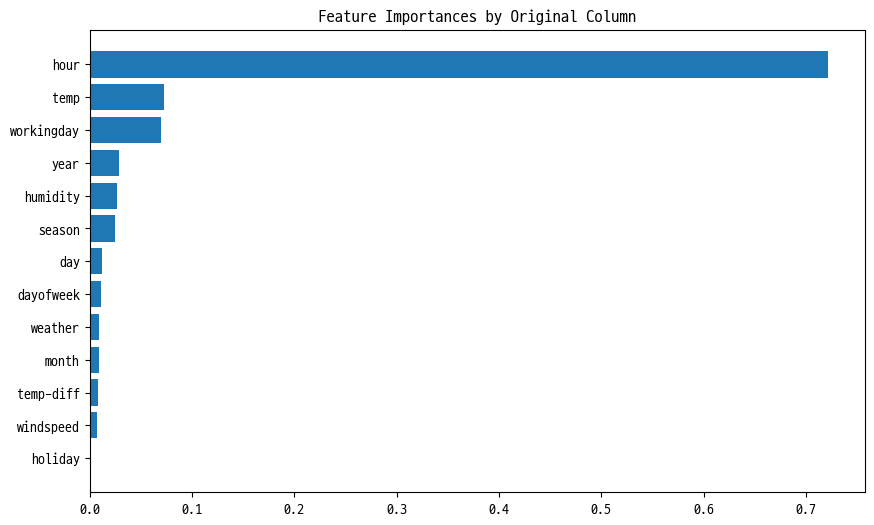

In [95]:
# 5. 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(grouped_importance['Original_Feature'][:15], grouped_importance['Importance'][:15])
plt.gca().invert_yaxis()
plt.title("Feature Importances by Original Column")
plt.show()

In [92]:
feature_names

array(['cat__day_1', 'cat__day_2', 'cat__day_3', 'cat__day_4',
       'cat__day_5', 'cat__day_6', 'cat__day_7', 'cat__day_8',
       'cat__day_9', 'cat__day_10', 'cat__day_11', 'cat__day_12',
       'cat__day_13', 'cat__day_14', 'cat__day_15', 'cat__day_16',
       'cat__day_17', 'cat__day_18', 'cat__day_19', 'cat__dayofweek_0',
       'cat__dayofweek_1', 'cat__dayofweek_2', 'cat__dayofweek_3',
       'cat__dayofweek_4', 'cat__dayofweek_5', 'cat__dayofweek_6',
       'cat__holiday_0', 'cat__holiday_1', 'cat__hour_0', 'cat__hour_1',
       'cat__hour_2', 'cat__hour_3', 'cat__hour_4', 'cat__hour_5',
       'cat__hour_6', 'cat__hour_7', 'cat__hour_8', 'cat__hour_9',
       'cat__hour_10', 'cat__hour_11', 'cat__hour_12', 'cat__hour_13',
       'cat__hour_14', 'cat__hour_15', 'cat__hour_16', 'cat__hour_17',
       'cat__hour_18', 'cat__hour_19', 'cat__hour_20', 'cat__hour_21',
       'cat__hour_22', 'cat__hour_23', 'cat__month_1', 'cat__month_2',
       'cat__month_3', 'cat__month_4', 'cat_

## HGB vs RFR 비교 피드백

### 결과 요약
- **HGB**: RMSLE **0.298**, RMSE 43.344, MAE 25.894
- **RFR**: RMSLE **0.330**, RMSE 45.456, MAE 27.590

➡️ **HGB가 3개 지표 모두 우세**합니다.  
- RMSLE 기준으로도 HGB가 확실히 낮고(0.298 < 0.330),
- RMSE/MAE도 함께 더 좋습니다.

### 해석
- 이 데이터(시간대+날씨 기반)는 **부스팅 계열이 랜덤포레스트보다 더 잘 맞는 패턴**이 흔합니다.  
  부스팅은 “잔차를 순차적으로 보정”해서 복잡한 비선형을 더 세밀하게 잡는 경향이 있어요.
- RFR은 튜닝을 해도 HGB 수준까지 따라붙을 때가 있지만, 대개 **깊이/leaf 제한을 잘 걸어야** 하고, 그래도 부스팅이 앞서는 경우가 많습니다.

### 다음 개선 포인트 (한 스텝 후보)
1) **RFR 튜닝으로 따라붙을 여지 확인**
   - `min_samples_leaf`를 키우면 일반화가 좋아지는 경우가 많아요.
   - 추천 1차: `min_samples_leaf=5` 또는 `10`, 그리고 `max_features="sqrt"`  
2) **HGB 튜닝으로 추가 개선 노리기 (더 유망)**
   - `max_depth`(6/8/10) 또는 `learning_rate/max_iter` 조합 2~3개만 비교
3) **검증 신뢰도 강화**
   - 랜덤 홀드아웃에서 크게 좋아진 모델은 **시간기반 검증**으로 재확인이 중요합니다.

# XGB, LGBM 추가 비교 

일반적으로 부스팅 lgbm 알고리즘이 성능이 잘 나옴 > 추가 요구함.

## train_and_evaluate() 정의
모델별 학습/예측/평가 파이프라인 실행 함수

In [23]:
# 모델 1개 학습/예측/평가를 동일 규칙으로 수행하는 함수 추가

import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.compose import TransformedTargetRegressor # 타겟 변환용

def optimize_and_train(prep, model, param_grid, X_train, y_train):
    """
    - model: sklearn 호환 regressor
    - prep: 이미 만들어 둔 전처리기(preprocess 또는 preprocess_hgb 등)
    """
    model_pipe = Pipeline([
        ("prep", prep),
        ("model", model)
    ])
    
    # 2. 타겟 로그 변환 적용 (TransformedTargetRegressor)
    # 파이프라인 전체를 감싸서 데이터 전처리부터 타겟 변환까지 한 번에 관리합니다.
    model_tt = TransformedTargetRegressor(
        regressor=model_pipe,
        func=np.log1p, inverse_func=np.expm1
    )
    
    # 3. GridSearchCV 객체 생성 (5-fold 교차 검증 사용)
    grid_search = GridSearchCV(model_tt, param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=1)

    # 4. 학습 (X_train, y_train은 앞서 변환한 NumPy 배열)
    # X_train_scaled가 아닌, 전처리가 포함되지 않은 원본 X_train을 넣어야 합니다. (파이프라인이 처리함)
    grid_search.fit(X_train, y_train)

    # 5. 최적의 결과 확인
    print(f"최적 파라미터: {grid_search.best_params_}")

    # 6. 최적의 모델 추출
    model_opt = grid_search.best_estimator_
    
    return model_opt

def predict_and_evaluate(model, x_test, y_test) :
    pred = model.predict(X_test)
    pred = np.maximum(0, pred)
    evaluate_model_performance(y_test, pred)
    
def train_and_evaluate(prep, model, name, X_train, y_train, X_test):
    """
    - model: sklearn 호환 regressor
    - preprocess_used: 이미 만들어 둔 전처리기(preprocess 또는 preprocess_hgb 등)
    """
    pipe = Pipeline([
        ("prep", prep),
        ("model", model)
    ])
    pipe.fit(X_train, np.log1p(y_train))
    pred = np.expm1(pipe.predict(X_test))
    pred = np.maximum(0, pred)  # rmsle(log1p) 보호 + count 도메인 반영
    print(f"\n[{name}]")
    evaluate_model_performance(y_test, pred)

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# 1) 컬럼 타입 구분

# categorical_cols = ["season","holiday","workingday","weather","year","month","day","hour","dayofweek"]
num_cols = ["temp","temp-diff","humidity","windspeed"]
cat_cols = X.columns.difference(num_cols)  # 숫자형 제외
 
# 2) 전처리: 범주형 원핫 + 수치형 스케일
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols),
    ],
    remainder="drop"
)

In [28]:
from xgboost import XGBRegressor
# 1) XGBRegressor

param_grid = {
    # 'regressor__model__n_estimators': [500, 1000, 2000],        # 생성할 결정 트리의 개수
    'regressor__model__learning_rate': [0.03, 0.05, 0.1],     # 학습률 (낮을수록 n_estimators는 높게 설정 권장)
    'regressor__model__max_depth': [5, 7, 10],                 # 트리의 최대 깊이 (과적합 제어 핵심)
    # 'regressor__model__min_child_weight': [1, 3, 5],          # 트리 분할을 위한 최소 가중치 합
    'regressor__model__subsample': [0.7, 0.8, 0.9],           # 각 트리 학습에 사용할 데이터 샘플링 비율
    'regressor__model__colsample_bytree': [0.7, 0.8, 0.9]     # 각 트리 학습에 사용할 피처(컬럼) 샘플링 비율
}

try:
    from xgboost import XGBRegressor

    xgb = XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    )
    xgb_opt = optimize_and_train(preprocess, xgb, param_grid, X_train, y_train)
    predict_and_evaluate(xgb_opt, X_test, y_test)

except Exception as e:
    print("[XGBRegressor] 실행 실패:", type(e).__name__, str(e)[:200])


Fitting 5 folds for each of 81 candidates, totalling 405 fits
최적 파라미터: {'regressor__model__colsample_bytree': 0.9, 'regressor__model__learning_rate': 0.05, 'regressor__model__max_depth': 10, 'regressor__model__subsample': 0.7}
RMSLE: 0.292, RMSE: 40.100, MAE: 24.204
R-Square Score : 0.951


## XGBRegressor

In [29]:
from xgboost import XGBRegressor
# 1) XGBRegressor

try:
    from xgboost import XGBRegressor

    xgb = XGBRegressor(
        n_estimators=1000,  # 2000
        learning_rate=0.05,  # 0.03
        max_depth=7, # 8
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    )
    train_and_evaluate(preprocess, xgb, "XGBRegressor", X_train, y_train, X_test)

except Exception as e:
    print("[XGBRegressor] 실행 실패:", type(e).__name__, str(e)[:200])



[XGBRegressor]
RMSLE: 0.288, RMSE: 39.639, MAE: 24.068
R-Square Score : 0.952


## XGB 결과 피드백 (HGB/RFR와 비교)

### 결과 요약
- **HGB**: RMSLE 0.298 / RMSE 43.344 / MAE 25.894
- **RFR**: RMSLE 0.330 / RMSE 45.456 / MAE 27.590
- **XGB**: **RMSLE 0.289 / RMSE 39.047 / MAE 23.798** ✅

### 해석
- **XGB가 현재 1등**입니다.
  - RMSLE: 0.298 → **0.289** (개선)
  - RMSE/MAE도 함께 개선되어, 단순히 로그스케일만 좋아진 게 아니라 **절대 오차도 줄었습니다.**
- 즉, 지금 데이터/피처에서는 “선형 < RF < HGB < XGB” 흐름이 명확합니다.

### 다음 개선 포인트
1) **LGBM 추가 비교**
- 보통 이 문제에서 LGBM이 XGB보다 더 좋거나 비슷하게 나오는 케이스가 많아서(튜닝 전이라도),
  다음 한 스텝으로 LGBM을 동일 조건으로 돌려보는 게 합리적입니다.

2) **검증 신뢰도**
- 성능이 좋아진 만큼, 이후에는 시간기반 검증(예: 뒤쪽 기간을 통째로 valid로)로
  “미래 예측”에서도 유지되는지 확인하면 선택이 더 확실해집니다.

## LGBMRegressor

In [31]:
# [LGBMRegressor] 1회 비교 실행
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.02,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

train_and_evaluate(preprocess, lgbm, "LGBMRegressor", X_train, y_train, X_test)


[LGBMRegressor]
RMSLE: 0.297, RMSE: 40.776, MAE: 24.424
R-Square Score : 0.950


c:\Apps\MiniConda\envs\ml_edu\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## LGBM 결과 피드백 (XGB/HGB/RFR와 비교)

### 결과 요약
- **XGBRegressor**: ✅ RMSLE **0.289**, RMSE 39.047, MAE 23.798  (현재 1등)
- **LGBMRegressor**: RMSLE **0.296**, RMSE 40.762, MAE 24.512
- **HGB**: RMSLE 0.298, RMSE 43.344, MAE 25.894
- **RFR**: RMSLE 0.330, RMSE 45.456, MAE 27.590
- **Linear**: RMSLE ~0.581 (baseline)

### 해석
- LGBM은 HGB보다 약간 좋지만, **XGB가 모든 지표에서 더 좋습니다.**
- 현재 설정(학습률/트리수/깊이/리프수)이 XGB에 더 잘 맞았거나,
  LGBM은 같은 노력 대비 **파라미터(특히 num_leaves/min_data_in_leaf)** 조정 여지가 남아있는 상태로 보입니다.

### 다음 액션 추천 (한 스텝)
- 이제 “모델 선택”은 **XGB로 확정**해도 되는 근거가 충분합니다(현재 검증 기준 1등).
- 다음 한 스텝은 둘 중 하나가 가장 효율적입니다:
  1) **XGB 소규모 튜닝(3~5개 조합)**: max_depth / min_child_weight / subsample / colsample_bytree
  2) **시간기반 검증 전환**: 랜덤 홀드아웃이 아니라 날짜 후반부를 valid로 두고 “미래 예측 성능” 확인

# Decision Tree with Log-Scaling

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.compose import TransformedTargetRegressor

# 1. 기본 모델 설정
model_dt_base = DecisionTreeRegressor(random_state=42)

# 2. 로그 변환을 포함한 Regressor 생성
model_dt_tt = TransformedTargetRegressor(
    regressor=model_dt_base,
    func=np.log1p, 
    inverse_func=np.expm1
)

# 3. 하이퍼파라미터 그리드 설정
param_grid = {
    'regressor__max_depth': [None, 5, 10, 20],       # 트리의 최대 깊이
    'regressor__min_samples_split': [2, 5, 10],    # 노드 분할을 위한 최소 샘플 수
    'regressor__min_samples_leaf': [1, 2, 4],       # 리프 노드의 최소 샘플 수
    'regressor__max_features': [None, 'sqrt', 'log2'] # 분할 시 고려할 특성 수
}

# 4. GridSearchCV 객체 생성
grid_search_dt = GridSearchCV(
    model_dt_tt, 
    param_grid, 
    cv=5, 
    scoring='r2', 
    n_jobs=-1, 
    verbose=1
)

# 5. 학습 (X_train_scaled와 y_train 사용)
grid_search_dt.fit(X_train_scaled, y_train)

# 6. 최적의 모델 추출
best_model_dt = grid_search_dt.best_estimator_

# 7. 특성 중요도(Feature Importance) 확인
# 결정 트리는 coef_ 대신 feature_importances_를 사용합니다.
importances = best_model_dt.regressor_.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names, # 미리 정의된 컬럼명 리스트
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(f"최적 파라미터: {grid_search_dt.best_params_}")
print(f"최고 R2 점수: {grid_search_dt.best_score_:.4f}")
print("\n[특성 중요도")
print(feature_importance_df)

In [ ]:
# ==========================================
# 학습 후 예측 및 평가
# ==========================================
# 학습에 사용하지 않은 테스트용 문제(X_test)를 주고 예측해보기
# best_model_dt.fit(X_train_scaled, y_train)
y_pred = best_model_dt.predict(X_test_scaled)

# 실제 정답(y_test)과 모델이 예측한 값(y_pred)을 비교하여 정확도 계산
r2, rmse = get_model_performance(y_test, y_pred)